# 08 - Pre-processamento

## Conceito
Modelos aprendem melhor quando os dados estao em formato adequado. O
pre-processamento cobre:

- Tratamento de valores faltantes
- Codificacao de variaveis categoricas
- Escalonamento de features numericas
- Tratamento de outliers
- Engenharia de features

## Por que importa
- KNN, SVM, redes neurais e regressao regularizada sao sensiveis a escala
- Modelos lineares nao lidam com categoricas diretamente
- Valores faltantes quebram muitos algoritmos

## Regra de ouro
O pre-processamento deve ser ajustado APENAS no treino e aplicado no teste.
Usar fit_transform no treino e transform no teste. O Pipeline garante isso
automaticamente.

## 1. Escalonamento

- StandardScaler: media 0, desvio 1
- MinMaxScaler: intervalo [0, 1]
- RobustScaler: usa mediana e IQR (robusto a outliers)
- Normalizer: normaliza cada amostra (norma L1 ou L2)

In [11]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
import matplotlib.pyplot as plt

iris = load_iris()
X = iris.data #type: ignore

pad = StandardScaler().fit_transform(X)
minmax = MinMaxScaler().fit_transform(X)
robust = RobustScaler().fit_transform(X)

print("Original   media:", X.mean(axis=0).round(2), "desvio:", X.std(axis=0).round(2))
print("Standard   media:", pad.mean(axis=0).round(2), "desvio:", pad.std(axis=0).round(2))
print("MinMax     min  :", minmax.min(axis=0), "max:", minmax.max(axis=0))

Original   media: [5.84 3.06 3.76 1.2 ] desvio: [0.83 0.43 1.76 0.76]
Standard   media: [-0. -0. -0. -0.] desvio: [1. 1. 1. 1.]
MinMax     min  : [0. 0. 0. 0.] max: [1. 1. 1. 1.]


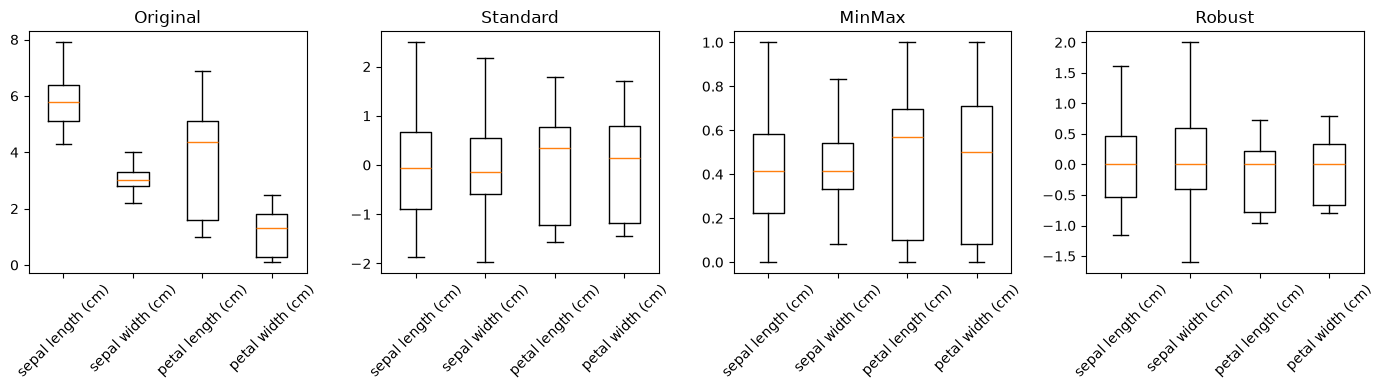

In [12]:
fig, axes = plt.subplots(1, 4, figsize=(14, 4))
titulos = ["Original", "Standard", "MinMax", "Robust"]
dados = [X, pad, minmax, robust]

for ax, titulo, d in zip(axes, titulos, dados):
    ax.boxplot(d, tick_labels=iris.feature_names, showfliers=False)  # type: ignore changed from labels=
    ax.set_title(titulo)
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

## 2. Codificacao de categoricas

- OneHotEncoder: cria uma coluna binaria por categoria
- OrdinalEncoder: mapeia categorias para inteiros (util quando ha ordem)
- LabelEncoder: apenas para a variavel alvo

In [13]:
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder

df = pd.DataFrame({
    "cor": ["azul", "verde", "azul", "vermelho", "verde"],
    "tamanho": ["P", "M", "G", "M", "P"],
    "preco": [10, 20, 30, 25, 15],
})

# One-hot
ohe = OneHotEncoder(sparse_output=False)
ohe_array = ohe.fit_transform(df[["cor"]])
print("Colunas one-hot:", ohe.get_feature_names_out())
print(ohe_array)
print()

# Ordinal (com ordem explicita)
oe = OrdinalEncoder(categories=[["P", "M", "G"]])
df["tamanho_cod"] = oe.fit_transform(df[["tamanho"]])
print(df)

Colunas one-hot: ['cor_azul' 'cor_verde' 'cor_vermelho']
[[1. 0. 0.]
 [0. 1. 0.]
 [1. 0. 0.]
 [0. 0. 1.]
 [0. 1. 0.]]

        cor tamanho  preco  tamanho_cod
0      azul       P     10          0.0
1     verde       M     20          1.0
2      azul       G     30          2.0
3  vermelho       M     25          1.0
4     verde       P     15          0.0


## 3. Valores faltantes

- SimpleImputer: preenche com media, mediana, moda ou constante
- KNNImputer: usa vizinhos para estimar
- Remover linhas ou colunas (ultimo recurso)

In [14]:
from sklearn.impute import SimpleImputer

df_faltante = pd.DataFrame({
    "idade": [25, np.nan, 30, 22, np.nan, 40],
    "salario": [3000, 4500, np.nan, 2800, 5000, np.nan],
})

print("Antes:")
print(df_faltante)

imp_media = SimpleImputer(strategy="mean")
df_media = pd.DataFrame(imp_media.fit_transform(df_faltante), columns=df_faltante.columns)

imp_mediana = SimpleImputer(strategy="median")
df_mediana = pd.DataFrame(imp_mediana.fit_transform(df_faltante), columns=df_faltante.columns)

print("\nCom media:")
print(df_media)
print("\nCom mediana:")
print(df_mediana)

Antes:
   idade  salario
0   25.0   3000.0
1    NaN   4500.0
2   30.0      NaN
3   22.0   2800.0
4    NaN   5000.0
5   40.0      NaN

Com media:
   idade  salario
0  25.00   3000.0
1  29.25   4500.0
2  30.00   3825.0
3  22.00   2800.0
4  29.25   5000.0
5  40.00   3825.0

Com mediana:
   idade  salario
0   25.0   3000.0
1   27.5   4500.0
2   30.0   3750.0
3   22.0   2800.0
4   27.5   5000.0
5   40.0   3750.0


## 4. Pipeline

O Pipeline encadeia etapas e evita vazamento de dados. Ele ajusta apenas
no treino e aplica no teste, deixando o codigo limpo e seguro.

In [15]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score

# Dataset com tipos mistos
dados = pd.DataFrame({
    "idade": [25, 45, 35, 22, 30, 52, 40, 28, 33, 48],
    "salario": [3000, 8000, 5000, 2200, 4500, 12000, 7000, 3200, 5500, 9500],
    "cidade": ["SP", "RJ", "SP", "MG", "RJ", "SP", "MG", "SP", "RJ", "MG"],
    "comprou": [0, 1, 1, 0, 0, 1, 1, 0, 0, 1],
})

X = dados.drop(columns="comprou")
y = dados["comprou"]

num_cols = ["idade", "salario"]
cat_cols = ["cidade"]

preproc = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
])

pipe = Pipeline([
    ("preproc", preproc),
    ("modelo", LogisticRegression(max_iter=500)),
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

pipe.fit(X_train, y_train)
print("Acuracia teste:", round(pipe.score(X_test, y_test), 3))
print("Acuracia cv   :", round(cross_val_score(pipe, X, y, cv=3).mean(), 3))

Acuracia teste: 1.0
Acuracia cv   : 0.917


## Exercicios

1. Compare StandardScaler, MinMaxScaler e RobustScaler em um dataset com outliers.
2. Crie um Pipeline com SimpleImputer e RandomForestClassifier para um dataset com valores faltantes.
3. Use ColumnTransformer para tratar colunas numericas e categoricas de forma distinta.
4. Explique com suas palavras por que fit_transform nao pode ser usado no conjunto de teste.